# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Juniyara Parisya Setiawan
- Email: parissajuniara@gmail.com
- Id Dicoding: juniyaraparisya

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from xgboost import XGBClassifier


import joblib

### Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/JunTheCoder62/Final-Project-Menyelesaikan-Permasalahan-Institusi-Pendidikan/refs/heads/main/Data/data.csv', delimiter=';')

In [3]:
df.head(5)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [5]:
df.isnull().sum()

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


tidak terdapat data yang memiliki missing value

In [6]:
df.duplicated().sum()

np.int64(0)

tidak terdapat data yang duplikat

In [7]:
df.nunique().sort_values(ascending = True)

,0
Daytime_evening_attendance,2
Displaced,2
Debtor,2
Educational_special_needs,2
International,2
Scholarship_holder,2
Gender,2
Tuition_fees_up_to_date,2
Status,3
Marital_status,6


Karena data sudah clean dan tidak memiliki missing value, data langsung digunakan.

In [8]:
df['Status'].nunique()

3

In [9]:
np.sort(df['Status'].unique())

array(['Dropout', 'Enrolled', 'Graduate'], dtype=object)

In [10]:
df['Status'].value_counts()

,count
Status,
Graduate,2209
Dropout,1421
Enrolled,794


### Encoder data dari Object/Categorical menjadi numerical

Dikarenakan permasalahan pada Jaya Jaya Institusi adalah siswa yang tidak menyelesaikan pendidikan, dan data yang adalah merupakan tipe data Object/Categorical sehingga data harus diubah menjadi Numerical.

In [11]:
Encoder = LabelEncoder()
df['Status'] = Encoder.fit_transform(df['Status'])
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2


In [12]:
# df_encoded = pd.get_dummies(df[['Status']], drop_first=True).astype(int)
# df_concat = pd.concat([df, df_encoded], axis=1)
# df_concat.head()

In [13]:
# label_encoder = LabelEncoder()
# df['Status_encoded'] = label_encoder.fit_transform(df['Status'])

# correlation_with_status = df.corr(numeric_only=True)['Status_encoded'].abs().sort_values(ascending=False)

# print("Correlation with 'Status' (absolute values, sorted descending):")
# print(correlation_with_status)

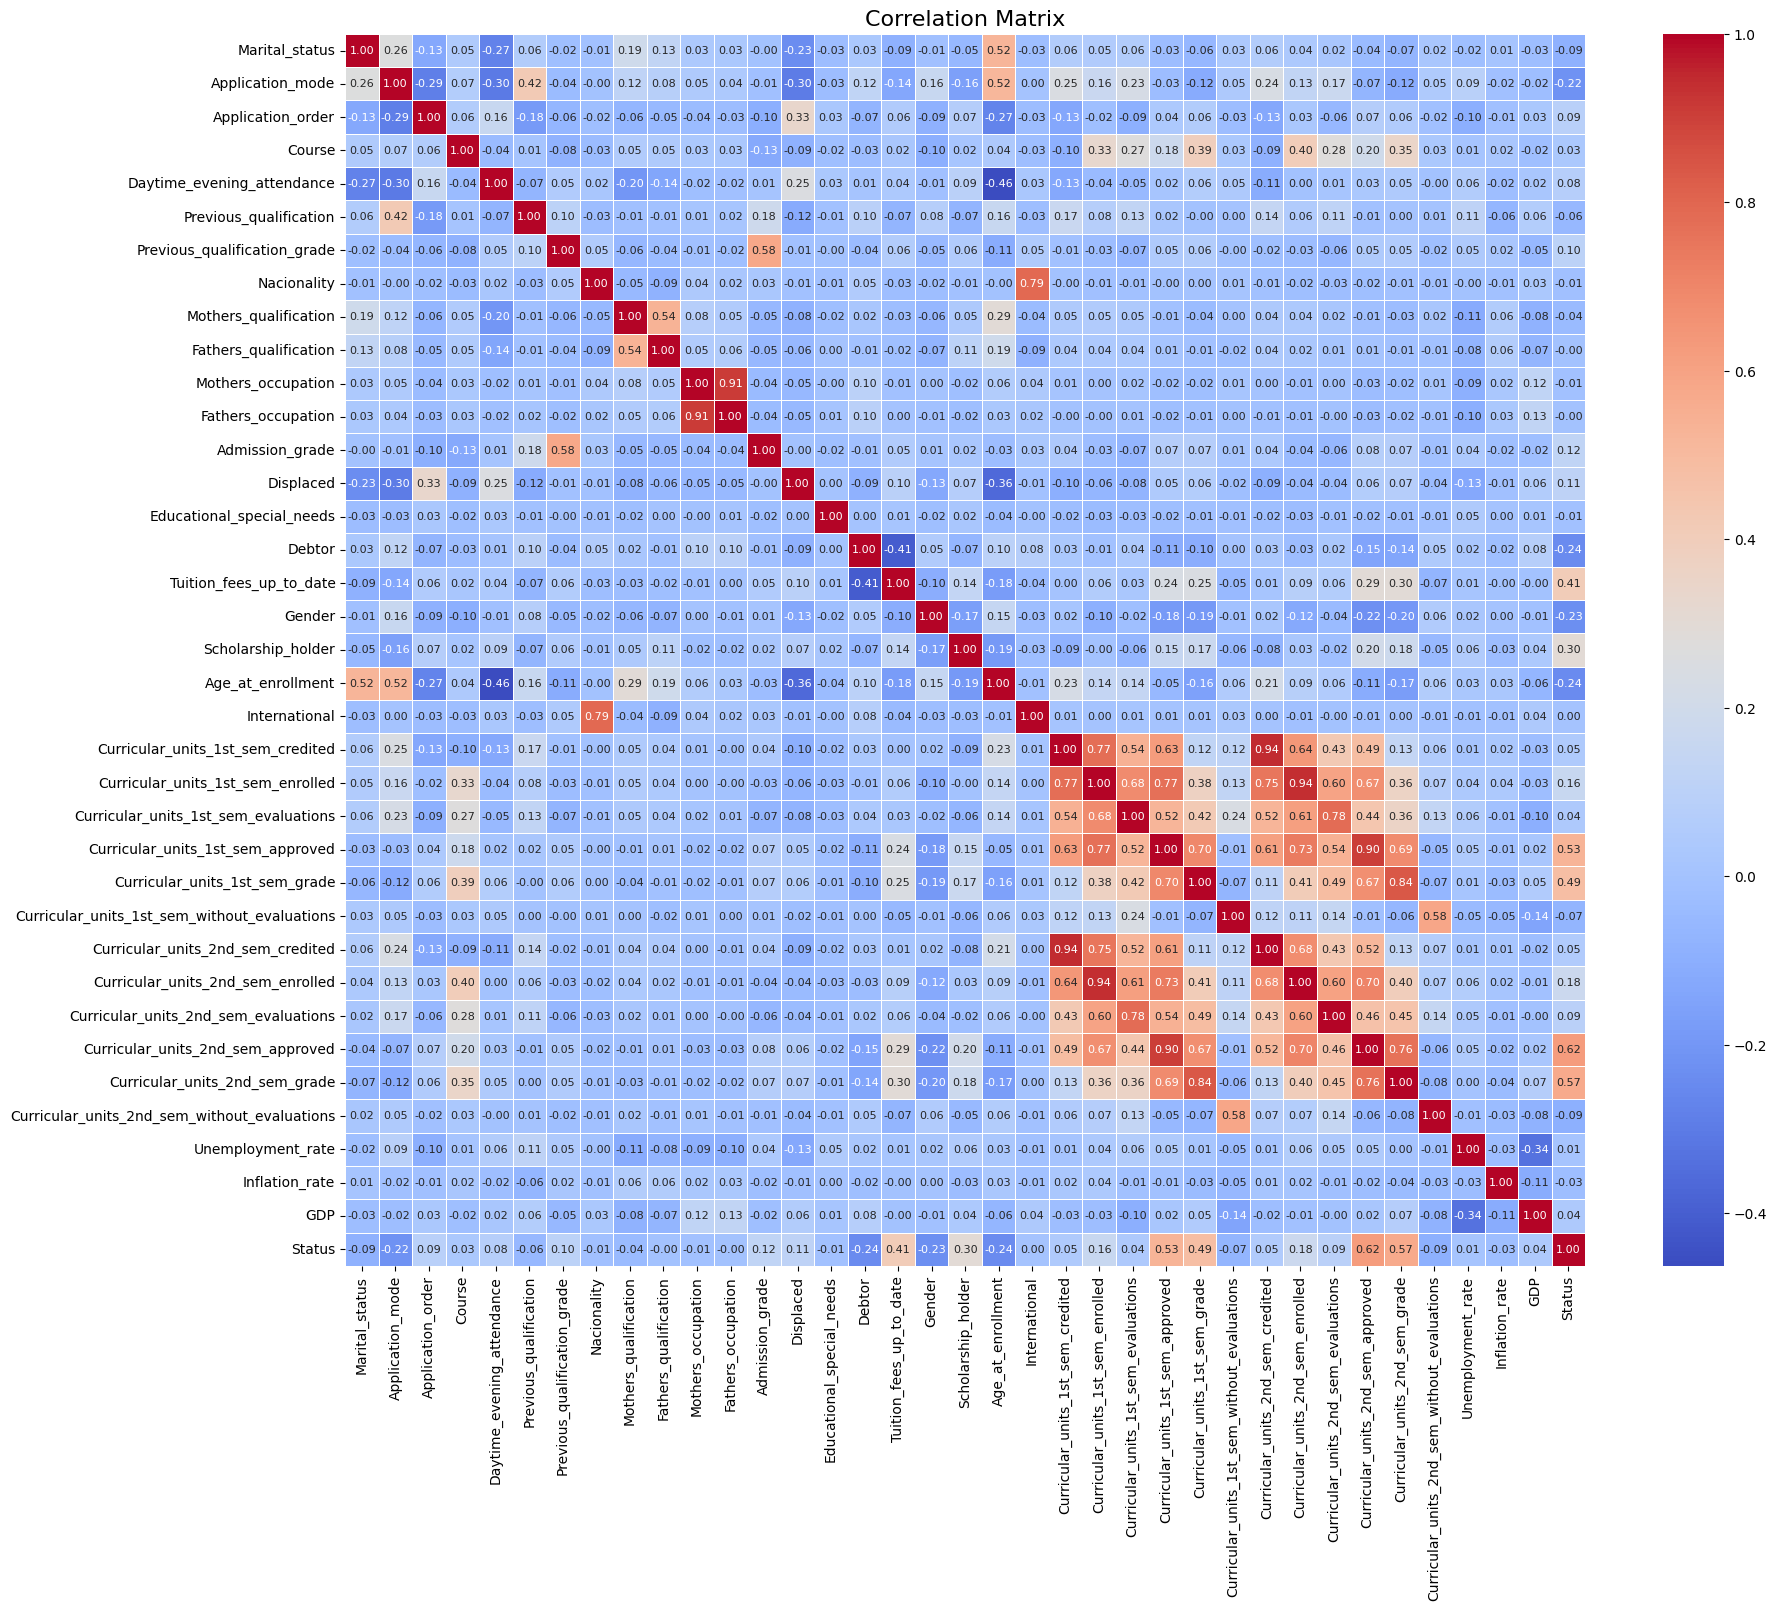

In [14]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt = ".2f", linewidths=0.5, annot_kws={"size": 8})
plt.title('Correlation Matrix', fontsize=16)
plt.show()

In [15]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_features].corr().abs()
correlation_status = correlation_matrix['Status'].sort_values(ascending=False)
correlation_status

,Status
Status,1.000000
Curricular_units_2nd_sem_approved,0.624157
Curricular_units_2nd_sem_grade,0.566827
Curricular_units_1st_sem_approved,0.529123
Curricular_units_1st_sem_grade,0.485207
Tuition_fees_up_to_date,0.409827
Scholarship_holder,0.297595
Age_at_enrollment,0.243438
Debtor,0.240999
Gender,0.229270


Didapat Matrix Korelasi untuk Status, dimana `Curricular_units_2nd_sem_approved` memiliki korelasi yang terbaik antara feature lainnya

In [16]:
df['Status'].value_counts()

,count
Status,
2,2209
0,1421
1,794


count Status  
- Graduate 2209
- Dropout 1421
- Enrolled 794


## Data Preparation / Preprocessing

In [17]:
median_status = df['Status'].median()
df['Status'].replace(2, median_status, inplace=True)

df['Status'] = df['Status'].astype(int)

print(df['Status'].value_counts())

Status
1    3003
0    1421
Name: count, dtype: int64


/tmp/ipykernel_4226/3144445059.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Status'].replace(2, median_status, inplace=True)


In [18]:
x = df.drop(columns=['Status'])
y = df['Status']

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [19]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((3539, 36), (885, 36), (3539,), (885,))

In [20]:
print([len(x_train), len(y_train)])
print([len(x_test), len(y_test)])

[3539, 3539]
[885, 885]


In [21]:
y_train.value_counts(normalize=True)

,proportion
Status,
1,0.678723
0,0.321277


In [22]:
y_test.value_counts(normalize=True)

,proportion
Status,
1,0.679096
0,0.320904


## Modeling

In [23]:
# Normalisasi Data
scaler = StandardScaler()
df['Status'] = scaler.fit_transform(df[['Status']])
print(df)

      Marital_status  Application_mode  Application_order  Course  \
0                  1                17                  5     171   
1                  1                15                  1    9254   
2                  1                 1                  5    9070   
3                  1                17                  2    9773   
4                  2                39                  1    8014   
...              ...               ...                ...     ...   
4419               1                 1                  6    9773   
4420               1                 1                  2    9773   
4421               1                 1                  1    9500   
4422               1                 1                  1    9147   
4423               1                10                  1    9773   

      Daytime_evening_attendance  Previous_qualification  \
0                              1                       1   
1                              1                   

In [24]:
# Random Forest
modem_rm = DecisionTreeClassifier()
modem_rm.fit(x_train, y_train)
predic_rf = modem_rm.predict(x_test)

print("akurasi:", accuracy_score(y_test, predic_rf))
print(classification_report(y_test, predic_rf))

akurasi: 0.8011299435028248
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       284
           1       0.85      0.85      0.85       601

    accuracy                           0.80       885
   macro avg       0.77      0.77      0.77       885
weighted avg       0.80      0.80      0.80       885



In [25]:
numerical_cols = ['Previous_qualification_grade', 'Admission_grade', 'Age_at_enrollment',
                  'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_evaluations',
                  'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations',
                  'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate',
                  'Inflation_rate', 'GDP']

categorical_cols = ['Application_mode', 'Application_order', 'Course', 'Mothers_qualification',
                    'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
                    'Displaced', 'Gender']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [26]:
X_train_processed = preprocessor.fit_transform(x_train)
X_test_processed = preprocessor.transform(x_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

In [27]:
xgb_model = Pipeline(steps=[
    ('classifier', XGBClassifier())
])

param_space_xgb = {
    'classifier__n_estimators': [10, 20 ,50, 100],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__gamma': [0.01, 0.1, 0.2, 0.3]
}

model_xgb = GridSearchCV(xgb_model, param_grid=param_space_xgb, cv=5)

model_xgb.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:", model_xgb.best_params_)
print("Training Accuracy:", model_xgb.score(X_train_resampled, y_train_resampled))
print("Model Best Score (XGBoost):", model_xgb.best_score_)
print("Test Accuracy:", model_xgb.score(X_test_processed, y_test))

Best Parameters: {'classifier__gamma': 0.01, 'classifier__max_depth': 7, 'classifier__n_estimators': 50}
Training Accuracy: 0.9539966694421316
Model Best Score (XGBoost): 0.8468121314602843
Test Accuracy: 0.8033898305084746


## Evaluation

In [28]:
y_pred_xgb = model_xgb.predict(X_test_processed)

print("\nConfusion Matrix XGBoost:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report XGBoost:")
print(classification_report(y_test, y_pred_xgb))


Confusion Matrix XGBoost:
[[154 130]
 [ 44 557]]

Classification Report XGBoost:
              precision    recall  f1-score   support

           0       0.78      0.54      0.64       284
           1       0.81      0.93      0.86       601

    accuracy                           0.80       885
   macro avg       0.79      0.73      0.75       885
weighted avg       0.80      0.80      0.79       885



In [29]:
joblib.dump(preprocessor, 'preprocessor_model.pkl')
joblib.dump(model_xgb, 'xgboost_model.pkl')

['xgboost_model.pkl']